# 03_IBD_GTstudentproject_train

This dataset associate OPs to their Biological Diatom Index (IBD; Prygiel & Coste, 2000) value, a index of river ecological quality estimated from inventories composition.

The file contains the following columns:

-   *SamplingOperations_code*: code of the diatom sampling operation.

-   *IBD*: raw IBD value. This value ranges from 0 (lowest ecological quality) to 20 (maximum ecological quality).

-   *IBD_EQR*: *Ecological quality ratio* of the IBD, computed from the raw IBD value and from thresholds specific to the hydroecoregion (HER) to which the OP site belongs. Details in French about the computation of these values can be found here (section 1.1.2.1): <https://www.legifrance.gouv.fr/jorf/id/JORFARTI000037347765>

-   *IBD_EQR_Status*: ecological quality status (*Bad*, *Poor*, *Moderate*, *Good* or *High*) estimated from the value of *IBD_EQR*.


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)

In [2]:
path = "../../data/raw/"
dfs = {}

# read all dataframes and keep them in dfs
for parquet in os.listdir(path):  # List all files in the directory
    if parquet.endswith(".parquet"):
        name = parquet.split(".parquet")[0]  # Get name without extension
        dfs[name] = pd.read_parquet(os.path.join(path, parquet))  # Use os.path.join for paths
        print(f"Loaded {name} with shape {dfs[name].shape}")

Loaded 01_DiatomInventories_GTstudentproject_B with shape (1643872, 8)
Loaded 02_InfoSites_GTstudentproject_B with shape (8404, 11)
Loaded 03_IBD_GTstudentproject_test with shape (5063, 2)
Loaded 03_IBD_GTstudentproject_train with shape (43783, 4)
Loaded 04_PressureStatus_GTstudentproject_B with shape (49231, 30)
Loaded 05_EnvParamMeans_GTstudentproject_B with shape (3763903, 8)
Loaded 06_ListEnvParam_GNNprojectGT_B with shape (192, 14)
Loaded 07_TaxaCode_GTstudentproject_B with shape (2292, 2)


In [28]:
df = dfs[list(dfs.keys())[3]] 
df

,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status
0,S04319000_20130724,5.2,0.256098,Bad
1,S06172100_20080716,6.1,0.298246,Bad
2,S03255920_20120802,3.7,0.157895,Bad
3,S04064720_20150710,4.9,0.228070,Bad
4,S05001500_20080726,5.3,0.251462,Bad
...,...,...,...,...
43778,S06165700_20230628,6.8,0.339181,Poor
43779,S06440770_20230524,15.3,0.836257,Good
43780,S06710030_20230627,18.4,1.000000,High
43781,S06036970_20230628,14.5,0.678571,Moderate


In [18]:
dfs[list(dfs.keys())[3]].nunique()

SamplingOperations_code    43573
IBD                          167
IBD_EQR                      605
IBD_EQR_Status                 5
dtype: int64

Text(0.5, 0, 'IBD_EQR')

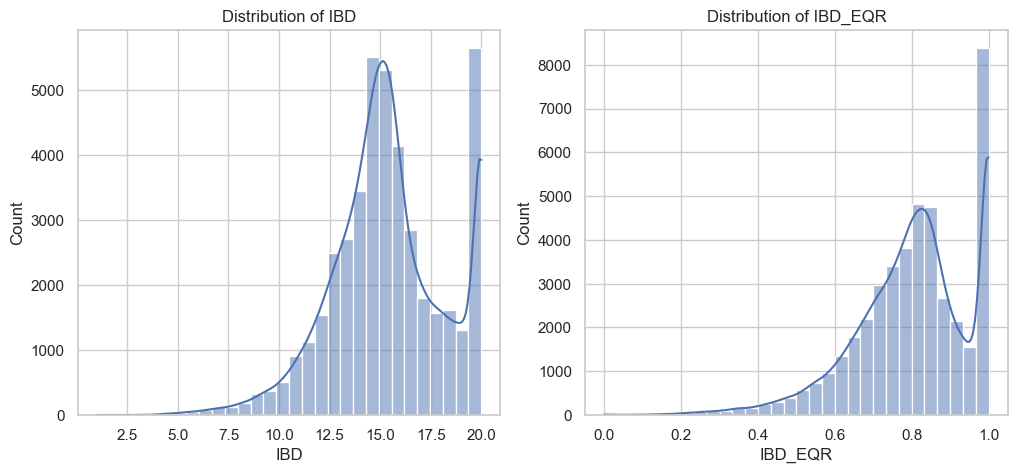

In [36]:
# distributions of IBD and IBD_EQR
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['IBD'], kde=True, bins=30)
plt.title('Distribution of IBD')
plt.xlabel('IBD')
plt.subplot(1, 2, 2)
sns.histplot(df['IBD_EQR'], kde=True, bins=30)
plt.title('Distribution of IBD_EQR')
plt.xlabel('IBD_EQR')

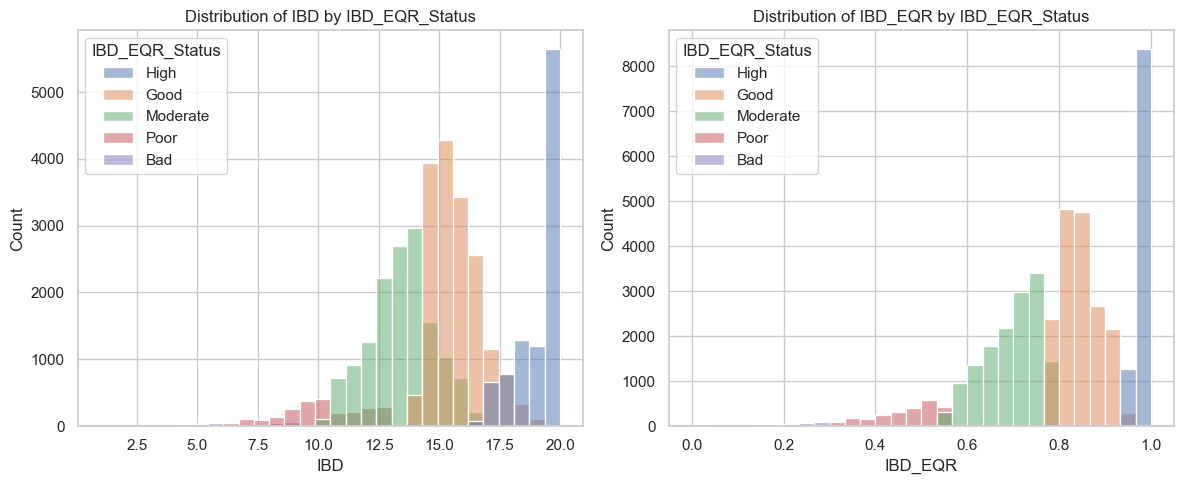

In [48]:
status_order = ['High', 'Good', 'Moderate', 'Poor', 'Bad']

# distributions of IBD and IBD_EQR classified by IBD_EQR_Status
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df, x='IBD', bins=30, hue='IBD_EQR_Status', hue_order=status_order)
plt.title('Distribution of IBD by IBD_EQR_Status')
plt.xlabel('IBD')
plt.subplot(1, 2, 2)
sns.histplot(df, x='IBD_EQR', bins=30, hue='IBD_EQR_Status', hue_order=status_order)
plt.title('Distribution of IBD_EQR by IBD_EQR_Status')
plt.xlabel('IBD_EQR')
plt.tight_layout()

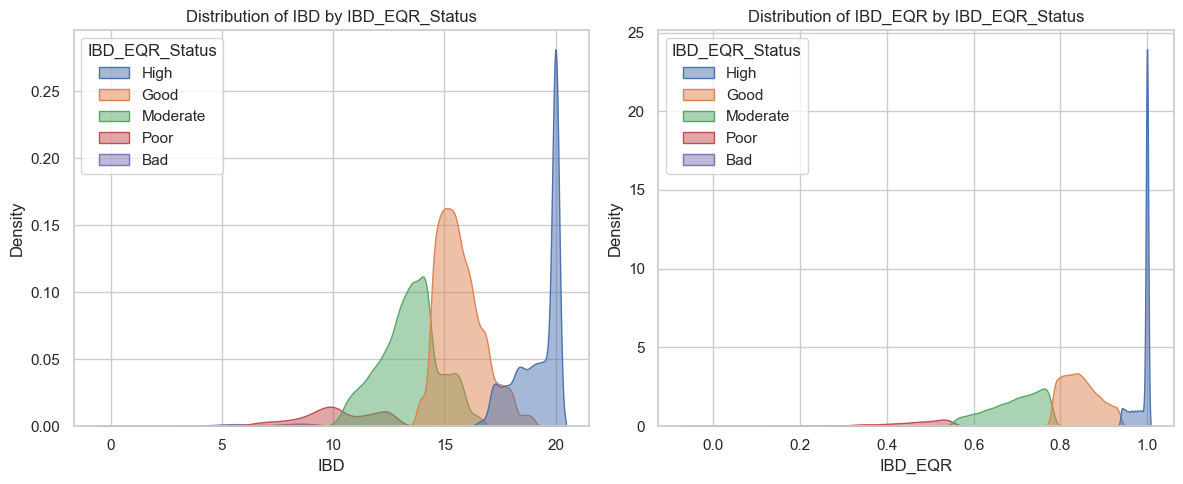

In [ ]:
# distributions of IBD and IBD_EQR classified by IBD_EQR_Status
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='IBD', hue='IBD_EQR_Status', hue_order=status_order, fill=True, alpha=0.5)
plt.title('Distribution of IBD by IBD_EQR_Status')
plt.xlabel('IBD')
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='IBD_EQR', hue='IBD_EQR_Status', hue_order=status_order, fill=True, alpha=0.5)
plt.title('Distribution of IBD_EQR by IBD_EQR_Status')
plt.xlabel('IBD_EQR')
plt.tight_layout()

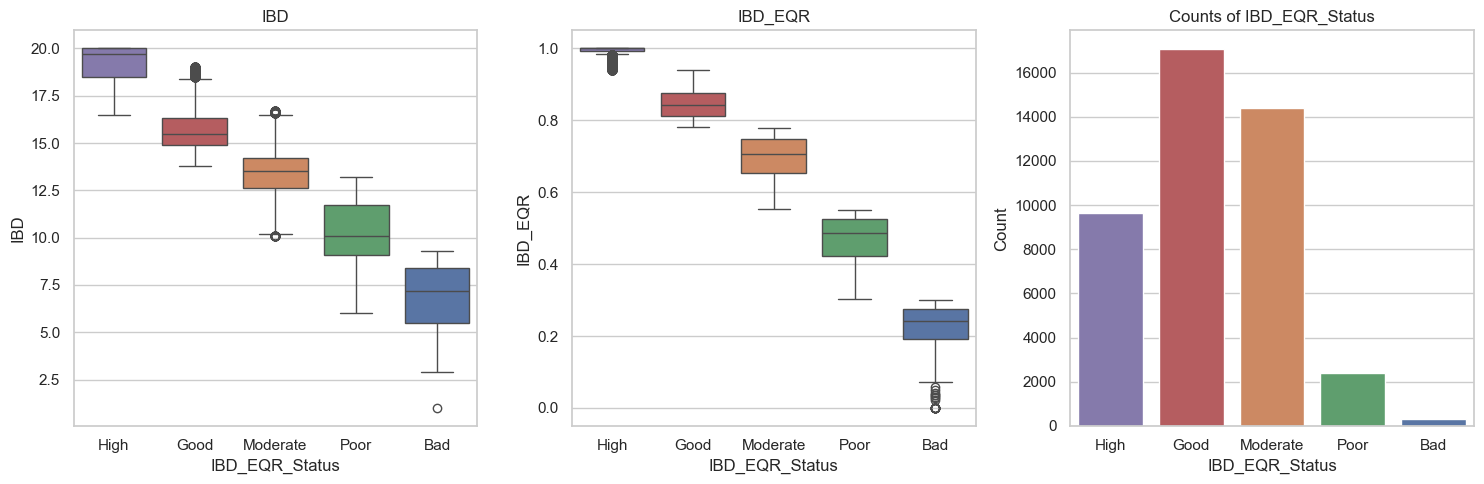

In [ ]:
plt.figure(figsize=(15, 5))

# Plot boxplots for each variable
for i, column in enumerate(['IBD', 'IBD_EQR'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df, x='IBD_EQR_Status', y=column, order=status_order, hue='IBD_EQR_Status')
    plt.title(f'{column}')
    plt.xlabel('IBD_EQR_Status')
    plt.ylabel(column)

# Add a count plot for IBD_EQR_Status
plt.subplot(1, 3, 3)
sns.countplot(data=df, x='IBD_EQR_Status', order=status_order, hue='IBD_EQR_Status')
plt.title('Counts of IBD_EQR_Status')
plt.xlabel('IBD_EQR_Status')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

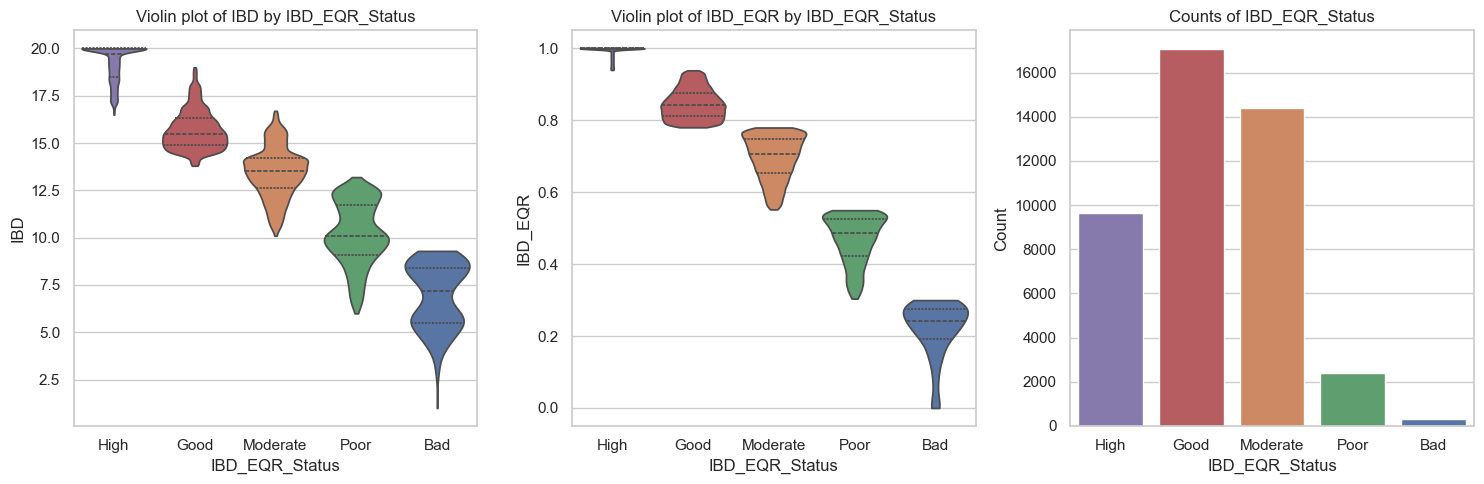

In [38]:
plt.figure(figsize=(15, 5))

# Plot violin plots for each variable
for i, column in enumerate(['IBD', 'IBD_EQR'], 1):
    plt.subplot(1, 3, i)
    sns.violinplot(data=df, x='IBD_EQR_Status', y=column, order=status_order, cut=0, inner='quartile', hue='IBD_EQR_Status')
    plt.title(f'Violin plot of {column} by IBD_EQR_Status')
    plt.xlabel('IBD_EQR_Status')
    plt.ylabel(column)

# Add a count plot for IBD_EQR_Status
plt.subplot(1, 3, 3)
sns.countplot(data=df, x='IBD_EQR_Status', order=status_order, hue='IBD_EQR_Status')
plt.title('Counts of IBD_EQR_Status')
plt.xlabel('IBD_EQR_Status')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

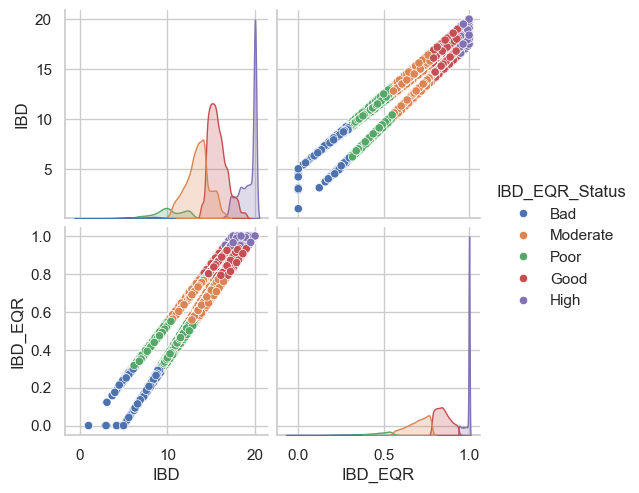

In [31]:
plt.figure(figsize=(10, 10))
sns.pairplot(df[['IBD', 'IBD_EQR', 'IBD_EQR_Status']], hue='IBD_EQR_Status')
plt.show()

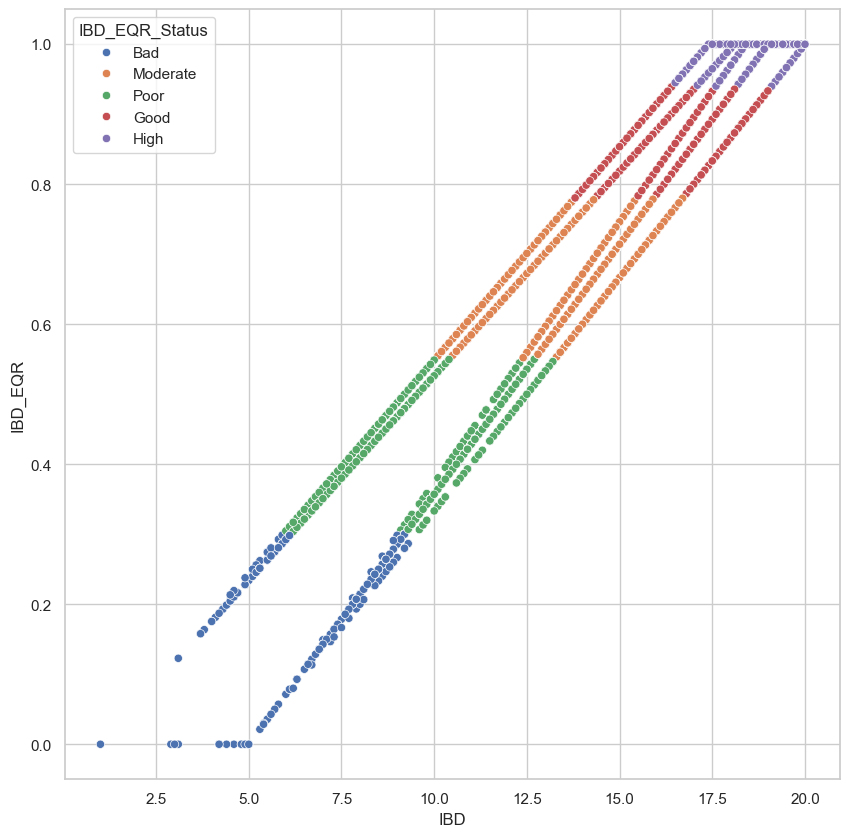

In [42]:
plt.figure(figsize=(10, 10))
sns.scatterplot(data=df, x='IBD', y='IBD_EQR', hue='IBD_EQR_Status')
plt.show()

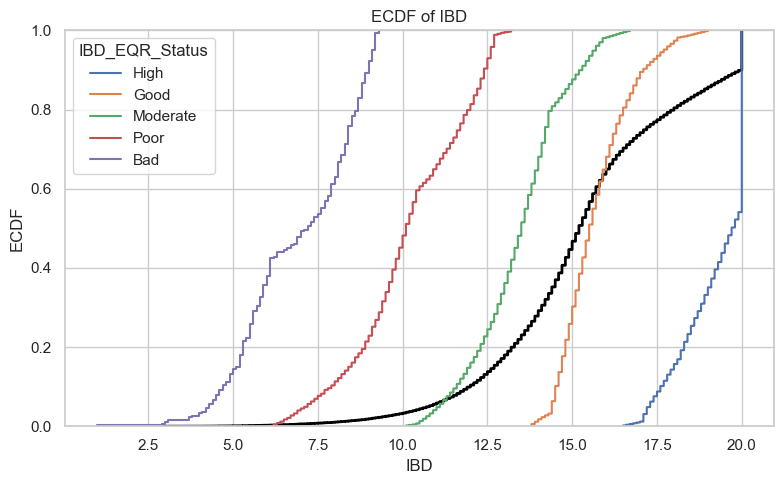

In [59]:
plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x="IBD", linewidth=2, color='black')
if "IBD_EQR_Status" in df:
    sns.ecdfplot(data=df, x="IBD", hue="IBD_EQR_Status", hue_order=status_order)
plt.title("ECDF of IBD")
plt.xlabel("IBD")
plt.ylabel("ECDF")
plt.tight_layout()

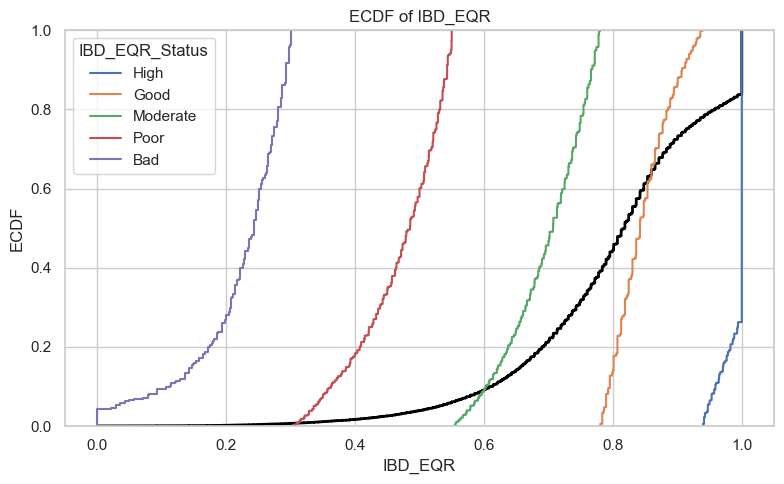

In [53]:
plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x="IBD_EQR", linewidth=2, color='black')
if "IBD_EQR_Status" in df:
    sns.ecdfplot(data=df, x="IBD_EQR", hue="IBD_EQR_Status", hue_order=status_order)
plt.title("ECDF of IBD_EQR")
plt.xlabel("IBD_EQR")
plt.ylabel("ECDF")
plt.tight_layout()